# H4 — LDI Bin Comparison

Hypothesis: LDI increases from Bin1 to Bin5.

We run paired one-sided t-tests on adjacent bins and apply Holm correction
(correction is required here).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import ttest_rel
from statsmodels.stats.multitest import multipletests

sns.set(style='whitegrid', context='talk')

df = pd.read_csv(r'C:\Users\Satyajit\Desktop\BRSM EXP\DATA\compiled_preprocessed.csv')


In [2]:
def load_map(path):
    out = {}
    for line in Path(path).read_text(encoding='utf-8').splitlines():
        if not line.strip():
            continue
        idx, b = line.strip().split()[:2]
        out[int(idx)] = int(b)
    return out

set6 = load_map(r"C:\Users\Satyajit\Desktop\BRSM EXP\MST_Data\item_only\Set6 bins.txt")
setsc = load_map(r"C:\Users\Satyajit\Desktop\BRSM EXP\MST_Data\item_only\SetScC bins.txt")

def infer_bin(image_path):
    x = pd.to_numeric(pd.Series([image_path]).str.extract(r'(\d+)')[0], errors='coerce').iloc[0]
    if pd.isna(x):
        return np.nan
    x = int(x)
    if 1 <= x <= 192:
        return set6.get(x, np.nan)
    if 193 <= x <= 384:
        return setsc.get(x - 192, np.nan)
    return np.nan

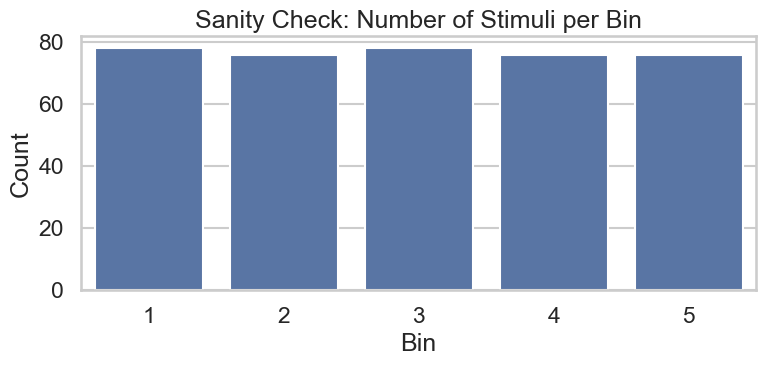

In [3]:
# Visualization: bin map sanity check
map_df = pd.DataFrame({
    'index': list(set6.keys()) + [k + 192 for k in setsc.keys()],
    'bin': list(set6.values()) + list(setsc.values())
}
)
plt.figure(figsize=(8, 4))
sns.countplot(data=map_df, x='bin', order=[1, 2, 3, 4, 5])
plt.title('Sanity Check: Number of Stimuli per Bin')
plt.xlabel('Bin')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [4]:
lure = df[df['trial_type'] == 'Lure'].copy()
lure['lure_bin'] = lure['image_path'].apply(infer_bin)

foil_base = (
    df[df['trial_type'] == 'Foil']
    .groupby(['participant_id', 'condition'])['user_response']
    .apply(lambda s: (s == 'Lure').mean())
    .rename('foil_sim')
    .reset_index()
)

bin_df = (
    lure[lure['lure_bin'].notna()]
    .groupby(['participant_id', 'condition', 'lure_bin'])['user_response']
    .apply(lambda s: (s == 'Lure').mean())
    .rename('lure_sim')
    .reset_index()
    .merge(foil_base, on=['participant_id', 'condition'], how='left')
)
bin_df['LDI_bin'] = bin_df['lure_sim'] - bin_df['foil_sim']
bin_df['id'] = bin_df['participant_id'].astype(str)

wide = bin_df.pivot(index='id', columns='lure_bin', values='LDI_bin').dropna()
print('Complete participants for bins:', len(wide))

Complete participants for bins: 160


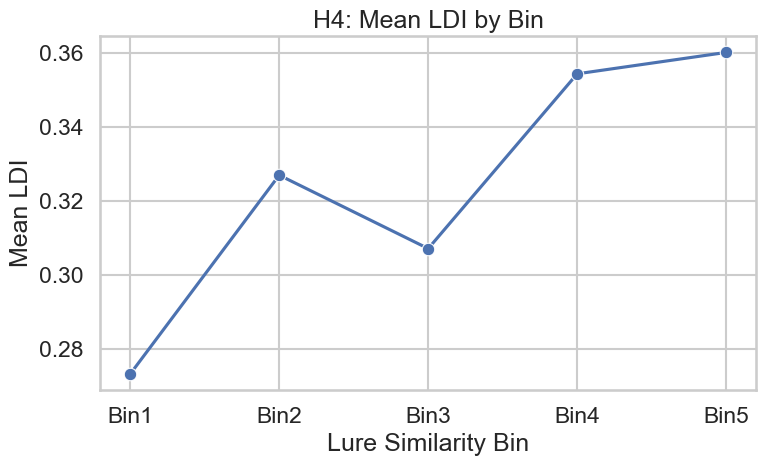

In [5]:
# Visualization: participant-level mean LDI per bin
bin_means = wide[[1, 2, 3, 4, 5]].mean().reset_index()
bin_means.columns = ['bin', 'mean_ldi']

plt.figure(figsize=(8, 5))
sns.lineplot(data=bin_means, x='bin', y='mean_ldi', marker='o')
plt.xticks([1, 2, 3, 4, 5], [f'Bin{i}' for i in [1, 2, 3, 4, 5]])
plt.title('H4: Mean LDI by Bin')
plt.xlabel('Lure Similarity Bin')
plt.ylabel('Mean LDI')
plt.tight_layout()
plt.show()

In [6]:
tests = []
pairs = [(2, 1), (3, 2), (4, 3), (5, 4)]
for a, b in pairs:
    test = ttest_rel(wide[a], wide[b], alternative='greater')
    tests.append({
        'comparison': f'Bin{a} > Bin{b}',
        'mean_diff': (wide[a] - wide[b]).mean(),
        't_stat': test.statistic,
        'p_raw': test.pvalue
    })

res = pd.DataFrame(tests)
res['p_adj_holm'] = multipletests(res['p_raw'], method='holm')[1]
res['supported (adj p<.05)'] = res['p_adj_holm'] < 0.05
display(res)

means = wide[[1, 2, 3, 4, 5]].mean().rename(index={1:'Bin1',2:'Bin2',3:'Bin3',4:'Bin4',5:'Bin5'})
display(means.to_frame('mean_LDI'))

,comparison,mean_diff,t_stat,p_raw,p_adj_holm,supported (adj p<.05)
0,Bin2 > Bin1,0.053688,3.368677,0.000474,0.001895,True
1,Bin3 > Bin2,-0.019827,-1.384229,0.915886,0.915886,False
2,Bin4 > Bin3,0.047193,3.127759,0.001048,0.003143,True
3,Bin5 > Bin4,0.005779,0.353604,0.362052,0.724104,False


,mean_LDI
lure_bin,
Bin1,0.273323
Bin2,0.327011
Bin3,0.307184
Bin4,0.354378
Bin5,0.360157


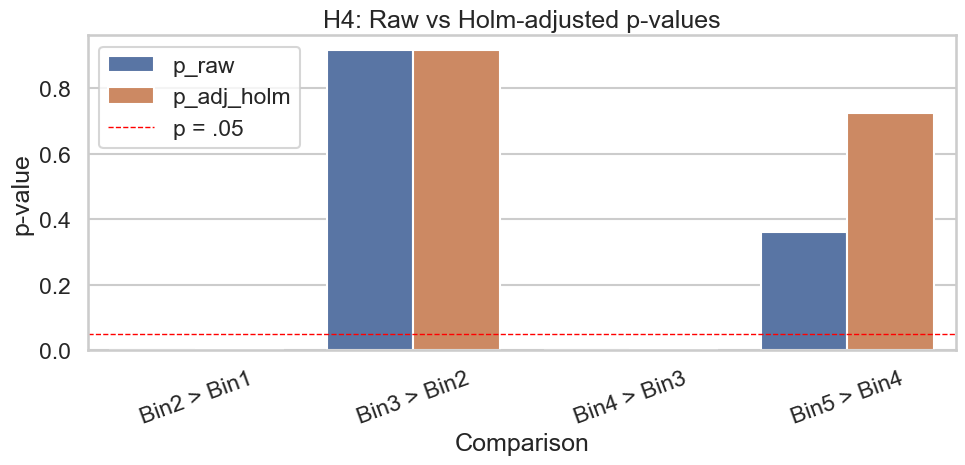

In [7]:
# Visualization: raw vs adjusted p-values (Holm)
p_plot = res.melt(id_vars='comparison', value_vars=['p_raw', 'p_adj_holm'], var_name='p_type', value_name='p')
plt.figure(figsize=(10, 5))
sns.barplot(data=p_plot, x='comparison', y='p', hue='p_type')
plt.axhline(0.05, color='red', linestyle='--', linewidth=1, label='p = .05')
plt.title('H4: Raw vs Holm-adjusted p-values')
plt.xlabel('Comparison')
plt.ylabel('p-value')
plt.xticks(rotation=20)
plt.legend()
plt.tight_layout()
plt.show()